Missing values per column:
 square_footage    5
bedrooms          5
bathrooms         5
age               5
neighborhood      5
price             0
dtype: int64


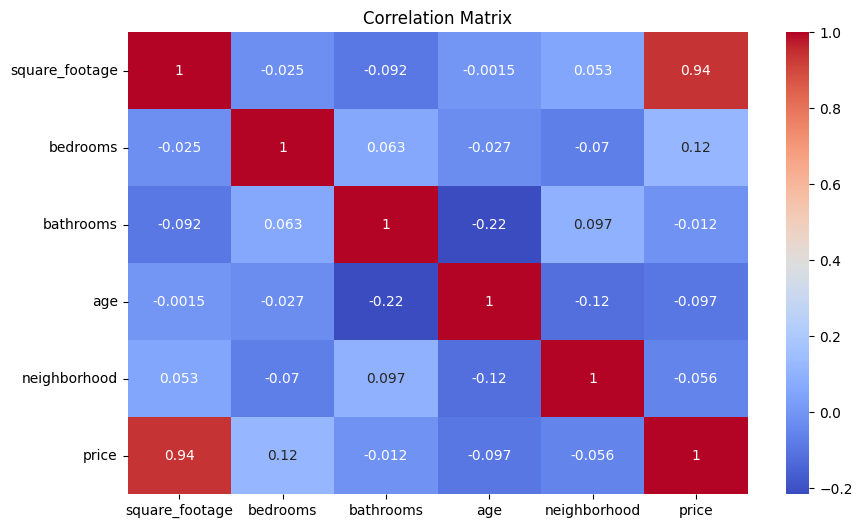

Mean Squared Error: 1876540016.5030334
R^2 Score: 0.5761221969814709
Predicted price for new house: 338653.6225974544


In [5]:
# ---------------------- TASK 1 ---------------------- #


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) 



num_samples = 100
df = pd.DataFrame({
    'square_footage': np.random.randint(1000, 3000, num_samples),
    'bedrooms': np.random.randint(2, 6, num_samples),
    'bathrooms': np.random.randint(1, 4, num_samples),
    'age': np.random.randint(0, 30, num_samples),
    'neighborhood': np.random.choice(['A', 'B', 'C'], num_samples)
})
neigh_map = {'A': 20000, 'B': 10000, 'C': 0}
df['price'] = (
    df['square_footage'] * 150
    + df['bedrooms'] * 10000
    + df['bathrooms'] * 5000
    - df['age'] * 1000
    + df['neighborhood'].map(neigh_map)
    + np.random.normal(0, 10000, num_samples)
)


for col in ['square_footage', 'bedrooms', 'bathrooms', 'age']:
    df.loc[df.sample(frac=0.05, random_state=42).index, col] = np.nan
df.loc[df.sample(frac=0.05, random_state=1).index, 'neighborhood'] = np.nan

print("Missing values per column:\n", df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)


for col in df.select_dtypes(include=['object', 'str']).columns:
    mode_val = df[col].mode()[0]
    df.fillna({col: mode_val}, inplace=True)



le = LabelEncoder()
df['neighborhood'] = le.fit_transform(df['neighborhood'])


plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


X = df.drop('price', axis=1)
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print('Mean Squared Error:', mean_squared_error(y_test, predictions))
print('R^2 Score:', r2_score(y_test, predictions))


neigh_num = le.transform(['B'])[0]
new_house_df = pd.DataFrame({
    'square_footage': [2000],
    'bedrooms': [3],
    'bathrooms': [2],
    'age': [10],
    'neighborhood': [neigh_num]
})
predicted_price = model.predict(new_house_df)
print('Predicted price for new house:', predicted_price[0])


In [6]:
# ---------------------- TASK 2 ---------------------- #

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random

def generate_email_dataset(n_samples=1000, random_state=42):
	random.seed(random_state)
	np.random.seed(random_state)
	spam_words = ["free", "win", "winner", "cash", "prize", "urgent", "offer", "buy", "cheap", "click"]
	ham_words = ["meeting", "project", "schedule", "report", "update", "team", "regards", "attached", "review", "thanks"]
	data = []
	for _ in range(n_samples):
		is_spam = np.random.binomial(1, 0.4)
		n_words = np.random.randint(5, 30)
		if is_spam:
			words = np.random.choice(spam_words, size=np.random.randint(2, 6)).tolist()
			words += np.random.choice(ham_words, size=n_words - len(words)).tolist()
			random.shuffle(words)
			text = " ".join(words)
			hyperlinks = np.random.binomial(1, 0.7)
			sender = random.choice(["promo@spam.com", "lottery@win.com", "offers@cheap.com", "unknown@random.com"])
		else:
			words = np.random.choice(ham_words, size=n_words).tolist()
			text = " ".join(words)
			hyperlinks = np.random.binomial(1, 0.1) 
			sender = random.choice(["boss@company.com", "colleague@work.com", "hr@company.com", "friend@email.com"])
		data.append({
			"email_text": text,
			"length": len(text),
			"hyperlinks": hyperlinks,
			"sender": sender,
			"spam": is_spam
		})
	return pd.DataFrame(data)

def preprocess(df):
	df = df.copy()
	df["sender"] = df["sender"].astype("category")
	sender_dummies = pd.get_dummies(df["sender"], prefix="sender")
	# Convert text to TF-IDF features
	tfidf = TfidfVectorizer(max_features=50)
	X_text = tfidf.fit_transform(df["email_text"]).toarray()
	X = np.concatenate([
		X_text,
		df[["length", "hyperlinks"]].values,
		sender_dummies.values
	], axis=1)
	y = df["spam"].values
	return X, y, tfidf

df = generate_email_dataset(n_samples=1000)
X, y, tfidf = preprocess(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

def classify_new_email(email_text, length, hyperlinks, sender, tfidf, model, sender_categories):
	sender_vec = np.zeros(len(sender_categories))
	if sender in sender_categories:
		sender_vec[sender_categories.index(sender)] = 1
	X_text = tfidf.transform([email_text]).toarray()[0]
	features = np.concatenate([
		X_text,
		[length, hyperlinks],
		sender_vec
	]).reshape(1, -1)
	pred = model.predict(features)[0]
	return pred

sender_categories = list(pd.get_dummies(df["sender"], prefix="sender").columns)
new_email = {
	"email_text": "free cash offer click urgent winner",
	"length": 35,
	"hyperlinks": 1,
	"sender": "promo@spam.com"
}
result = classify_new_email(
	new_email["email_text"],
	new_email["length"],
	new_email["hyperlinks"],
	new_email["sender"],
	tfidf,
	model,
	sender_categories
)
print("New email classified as:", "Spam" if result == 1 else "Not Spam")


Accuracy: 1.0
Confusion Matrix:
 [[121   0]
 [  0  79]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00        79

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

New email classified as: Spam


Model coefficients (hyperplane):
  total_spending: 1.826
  age: -0.216
  num_visits: 1.351
  purchase_freq: -0.008
Intercept: -3.065

Rules for classification (higher coef = more important):
  If total_spending increases, odds of being high-value increase (coef=1.83)
  If num_visits increases, odds of being high-value increase (coef=1.35)
  If age increases, odds of being high-value decrease (coef=-0.22)
  If purchase_freq increases, odds of being high-value decrease (coef=-0.01)

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        68
           1       0.40      0.29      0.33         7

    accuracy                           0.89        75
   macro avg       0.66      0.62      0.64        75
weighted avg       0.88      0.89      0.89        75

Confusion Matrix:
[[65  3]
 [ 5  2]]
Accuracy: 0.89


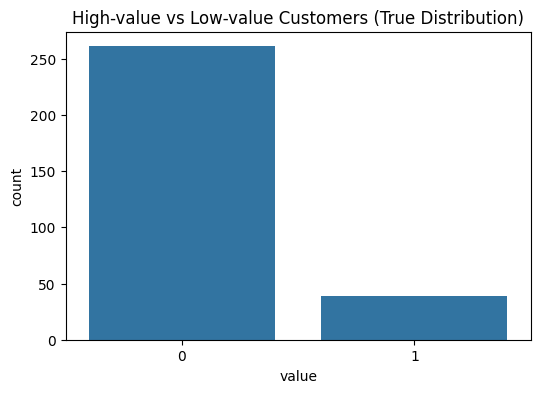

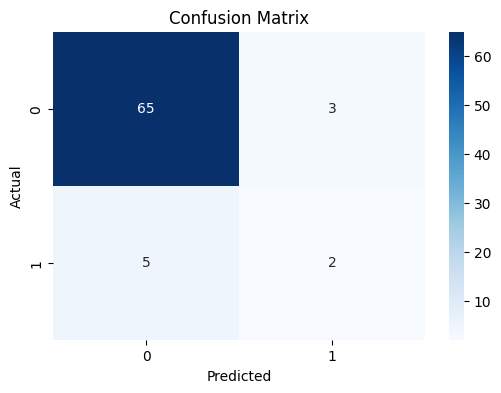

In [7]:
# ---------------------- TASK 3 ---------------------- #

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
num_samples = 300
data = pd.DataFrame({
	'total_spending': np.random.normal(1000, 400, num_samples).clip(100, 3000),
	'age': np.random.normal(35, 10, num_samples).clip(18, 70),
	'num_visits': np.random.poisson(10, num_samples),
	'purchase_freq': np.random.uniform(0.5, 5, num_samples)
})

data['value'] = ((data['total_spending'] > 1200) & (data['num_visits'] > 10)).astype(int)

data.loc[np.random.choice(num_samples, 5), 'age'] = np.nan
data.loc[np.random.choice(num_samples, 3), 'total_spending'] = 5000  # outliers


data['age'] = data['age'].fillna(data['age'].mean())

data = data.dropna(subset=['total_spending', 'age', 'num_visits', 'purchase_freq', 'value'])

data['total_spending'] = np.where(data['total_spending'] > 3000, 3000, data['total_spending'])

features = ['total_spending', 'age', 'num_visits', 'purchase_freq']
scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[features] = scaler.fit_transform(data[features])

X = data_scaled[features]
y = data_scaled['value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)

print("Model coefficients (hyperplane):")
for feat, coef in zip(features, clf.coef_[0]):
	print(f"  {feat}: {coef:.3f}")
print(f"Intercept: {clf.intercept_[0]:.3f}")

print("\nRules for classification (higher coef = more important):")
for feat, coef in sorted(zip(features, clf.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
	print(f"  If {feat} increases, odds of being high-value {'increase' if coef > 0 else 'decrease'} (coef={coef:.2f})")

y_pred = clf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

plt.figure(figsize=(6,4))
sns.countplot(x='value', data=data)
plt.title('High-value vs Low-value Customers (True Distribution)')
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
